In [1]:
from simple_neural_mpc.controllers import MPC
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.simulation.trajectory_tracking import (
    TrajectoryTrackingSimulation,
)
from simple_neural_mpc.utils import project_root

In [2]:
from simple_neural_mpc.neural_modeling.learner.mlp import MLP, Sine
import torch
from simple_neural_mpc.robots.unicycle import UnicycleState
from simple_neural_mpc.config.mpc_config import MPCConfig

model = MLP(3, 2, activation=torch.nn.Tanh(), in_mpc=True, is_pinn=True, is_highway=False)
model.load_state_dict(
    torch.load(
        # f"{project_root()}/simple_neural_mpc/neural_modeling/models/unicycle_60_epochs.pth",
        f"{project_root()}/simple_neural_mpc/neural_modeling/models/unicycle.pth",
        weights_only=True,
        map_location=torch.device("cpu"),
    ),
    strict=False,
)
model.eval()

robot = Unicycle(model)
controller = MPC(robot, to_generate=True)

/home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o acados_solver_unicycle.o acados_solver_unicycle.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_dyn_disc_phi_fun.o unicycle_model/unicycle_dyn_disc_phi_fun.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_dyn_disc_phi_fun_jac.o unicycle_model/unicycle_d

In file included from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1913,
                 from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1230:
/home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/neverorfrog/code/mpc-libs/acados/lib \
acados_ocp_solver_pyx.o \
/home/neverorfrog/code/simple_neural_mpc/simple_neural_mpc/scripts/acados_generated_files/c_generated_code/libacados_ocp_solver_unicycle.so \
-L/home/neverorfrog/code/mpc-libs/acados/lib -lacados -lhpipm -lblasfeo -lm


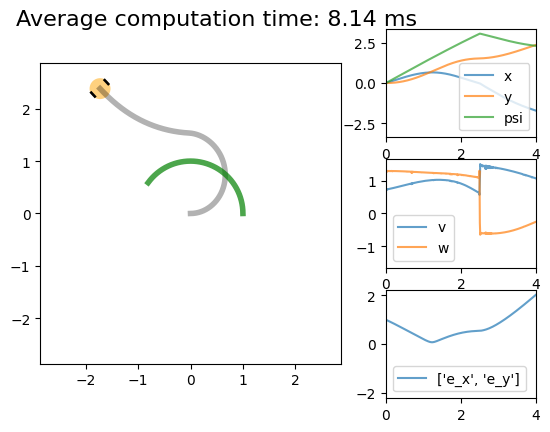

In [3]:
from simple_neural_mpc.simulation.trajectory import Dritto, Zero, Circle

reference = Circle(freq = 0.1, radius = 1)
# reference = Dritto()
# reference = Zero()
simulation = TrajectoryTrackingSimulation("mpc", robot, controller, reference)
simulation.t = 0
robot.state = UnicycleState(0, 0, 0)
simulation.run(N=400, animate=False, save=False)